In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("C:/Users/navan/Downloads/New folder/IMDb Movies India.csv",
                encoding="latin1"
                )

In [4]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [7]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [10]:
encoder = LabelEncoder()

df["Genre"] = encoder.fit_transform(df["Genre"])

df["Director"] = encoder.fit_transform(df["Director"])

df["Actor 1"] = encoder.fit_transform(df["Actor 1"])

df["Actor 2"] = encoder.fit_transform(df["Actor 2"])

df["Actor 3"] = encoder.fit_transform(df["Actor 3"])

In [11]:
df["Duration"] = df["Duration"].str.replace(" min","")
df["Duration"] = pd.to_numeric(df["Duration"])

In [12]:
df["Year"] = df["Year"].str.extract("(\d{4})")
df["Year"] = pd.to_numeric(df["Year"])

In [13]:
df["Votes"] = df["Votes"].str.replace(",","")
df["Votes"] = pd.to_numeric(df["Votes"])

In [14]:
X = df.drop(["Name","Rating"], axis=1)

y = df["Rating"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.8522429328621909
MSE: 1.2735831068904595
R2 Score: 0.31222493483299496


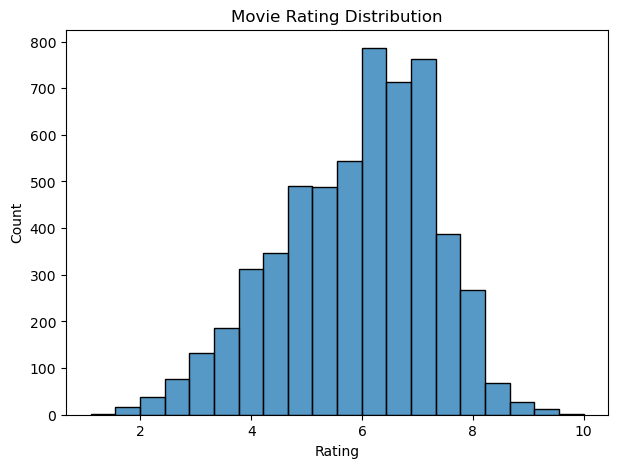

In [19]:
plt.figure(figsize=(7,5))

sns.histplot(df["Rating"], bins=20)

plt.title("Movie Rating Distribution")

plt.show()

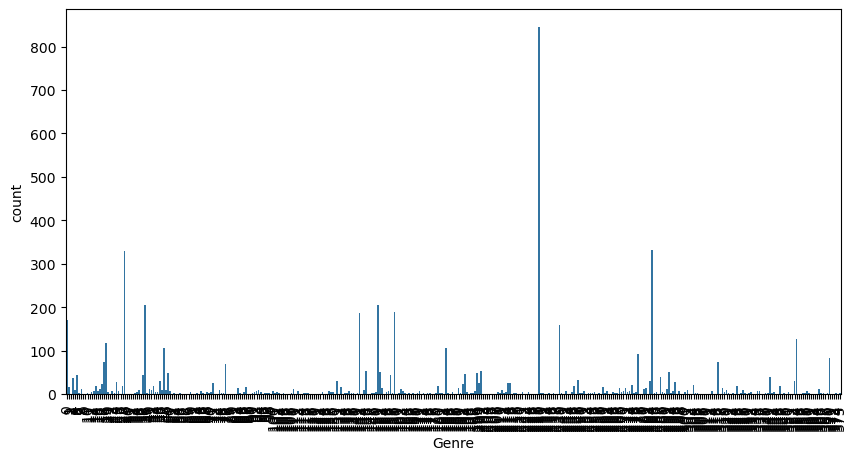

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(x="Genre", data=df)

plt.xticks(rotation=90)

plt.show()

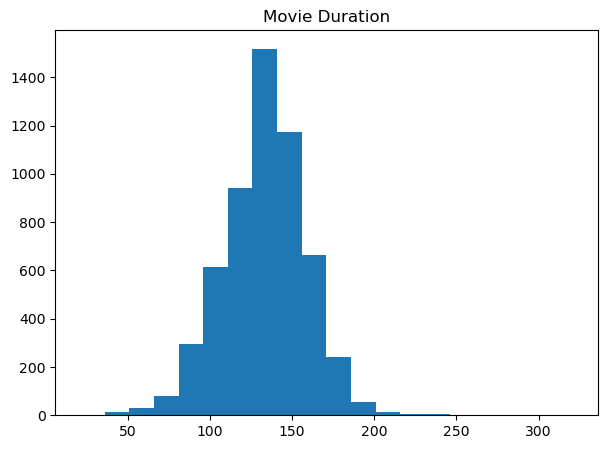

In [21]:
plt.figure(figsize=(7,5))

plt.hist(df["Duration"], bins=20)

plt.title("Movie Duration")

plt.show()

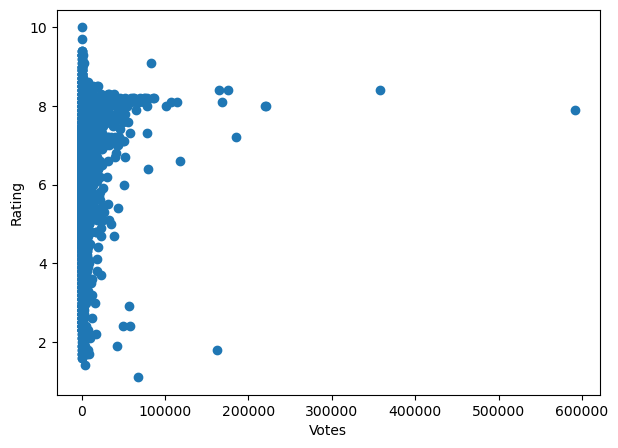

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(df["Votes"], df["Rating"])

plt.xlabel("Votes")

plt.ylabel("Rating")

plt.show()

In [25]:
results = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

results.head(10)

,Actual Rating,Predicted Rating
0,6.0,5.060
1,2.4,5.996
2,3.8,5.253
3,3.8,4.308
4,7.2,5.354
5,6.3,5.423
6,8.6,5.286
7,3.9,5.209
8,6.6,5.475
9,6.6,6.814


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
3,Votes,0.219652
0,Year,0.209200
2,Genre,0.137901
1,Duration,0.101243
5,Actor 1,0.089041
6,Actor 2,0.083370
7,Actor 3,0.082257
4,Director,0.077336


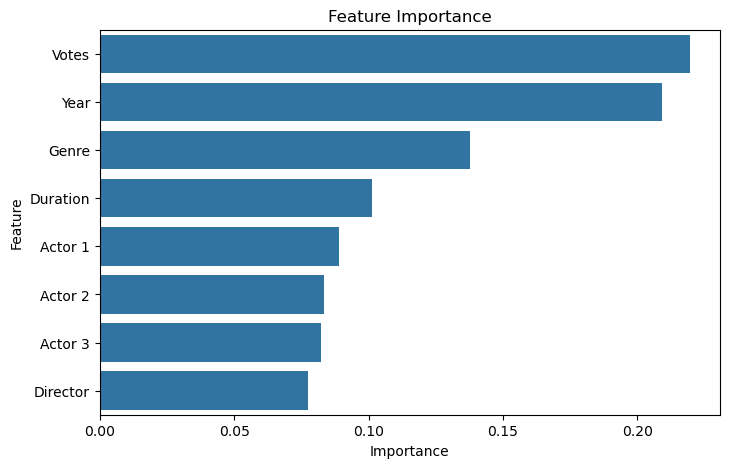

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [28]:
print("Movie Rating Prediction Project Completed Successfully")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 3))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 3))

Movie Rating Prediction Project Completed Successfully
R² Score: 0.312
Mean Absolute Error: 0.852
Mean Squared Error: 1.274
